In [1]:
import numpy as np
from matplotlib import pyplot as plt

import scienceplots
plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"mathtext.default": "regular"})

In [2]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlim(0.5, len(labels) + 0.5)

def plot_two_violions(desc, labels, dataset):
    cm = 1 / 2.54
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)
    pos = np.arange(0, 2)
    v1 = ax.violinplot(dataset=dataset, positions=pos+1, widths=0.5, showextrema=False, showmedians=True)
    
    med1 = v1['cmedians']
    med1.set_color('black')
    med1.set_linestyle('-')
    
    ax.set_ylabel(desc["y-axis"])
    ax.set_ylim(0, 1.0)
    set_axis_style(ax, labels)
    plt.show()

In [3]:
b2b_resnet_energy = np.loadtxt("/home/magnus/repos/ml-footprint-pred/paper1/b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv")

FileNotFoundError: /home/magnus/repos/ml-footprint-pred/paper1/b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv not found.

In [4]:
!pwd

/Users/magnus/repos/waam-e2e/e2e


In [9]:
trues = np.loadtxt("ys.csv", delimiter=",")
preds = np.loadtxt("mean_predictions.csv", delimiter=",")

In [14]:
from scipy.spatial.distance import cdist
modhaussdorff = []

for true, pred in zip(trues, preds):
    
    x = np.arange(0, len(preds) / 10, 0.1)
    
    dist = cdist(list(zip(x, true)), list(zip(x, pred)))
    modhaussdorff.append((np.median(np.min(dist, axis=1))))

In [15]:
np.array(modhaussdorff).shape

(56,)

In [18]:
dummy = np.random.rand(56)
dummy.shape

(56,)

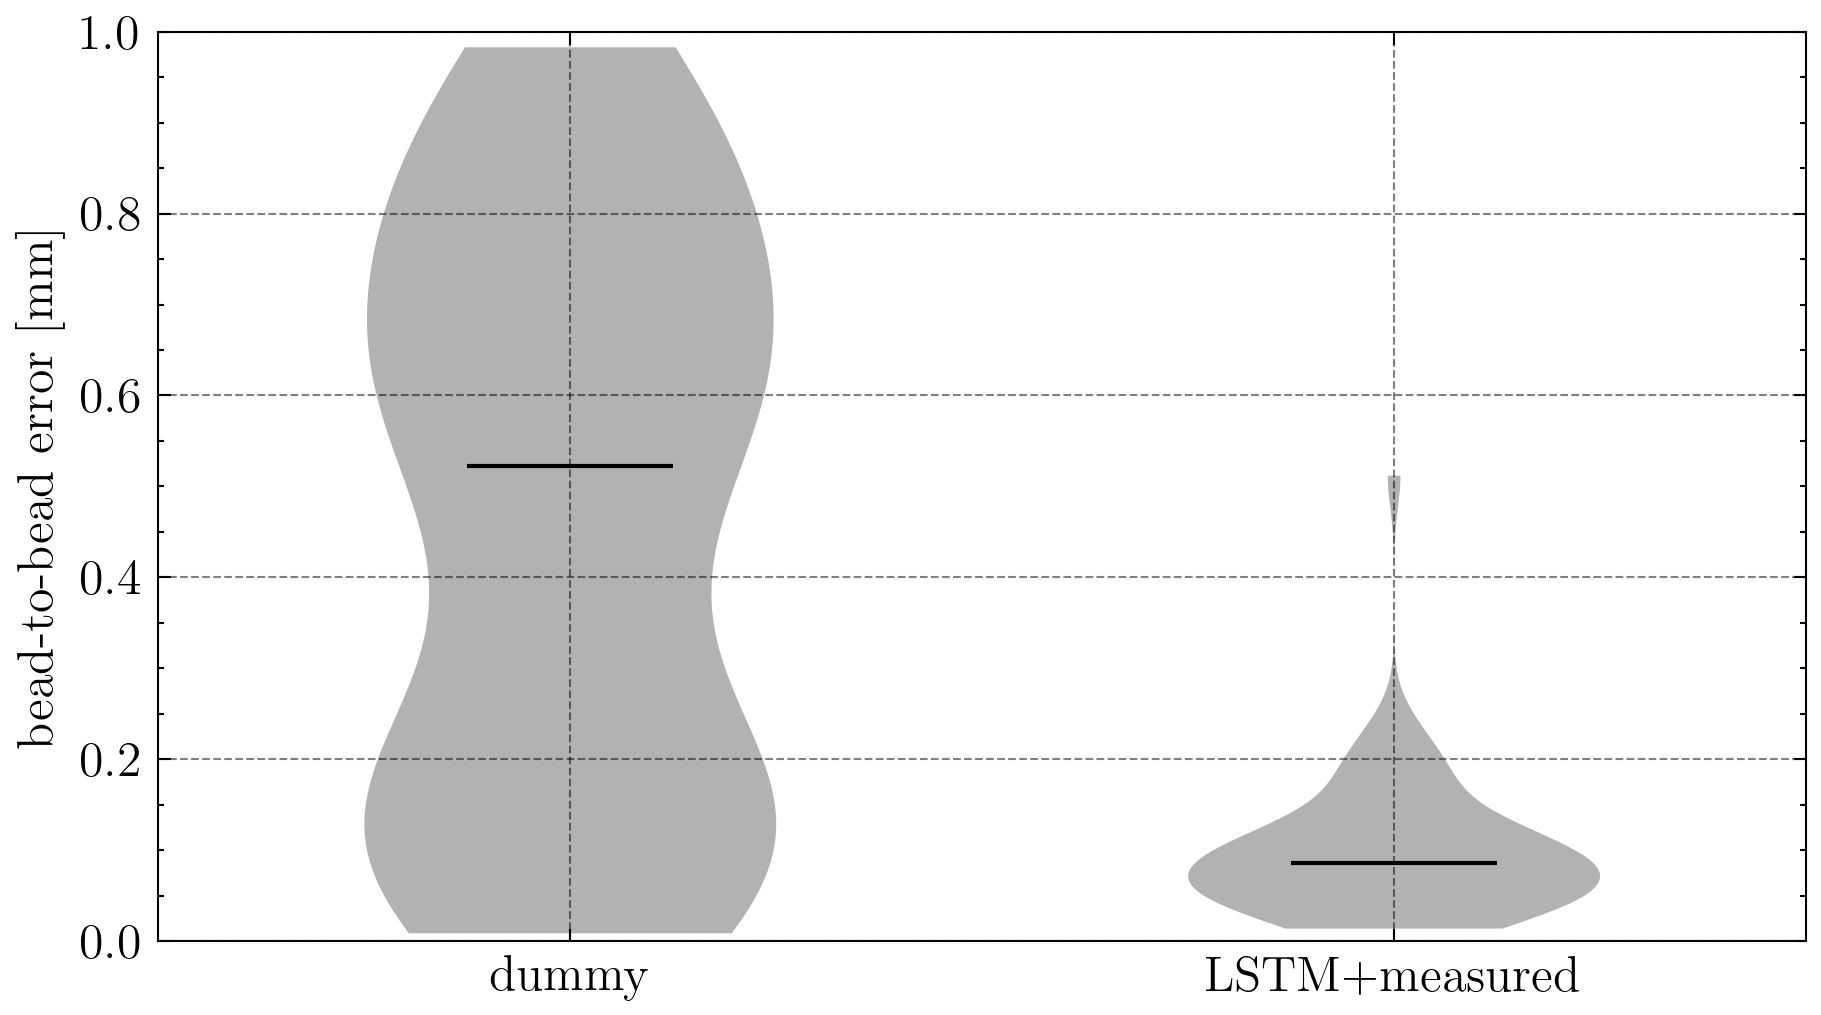

In [20]:
desc = {
    "title": "",
    "x-axis": "",
    "y-axis": "bead-to-bead error $[\mathrm{mm}]$"
}

labels = ["dummy", "LSTM+measured"]

plot_two_violions(desc, labels, [np.array(dummy), np.array(modhaussdorff)])